# Learning to rank Model

This notebook demonstrates the creation of a learning-to-rank model for a product recommendation system based on transaction data. The dataset `traintest.csv` contains order history with columns such as `user_id`, `product_id`, `reordered` (label). The process starts with data conversion to SQLite, exploration, preprocessing, feature creation, modeling with XGBoost LTR, ranking metric evaluation, and comparison with a baseline model. It concludes with an API function for predicting new data.

---

# Package Load

In [1]:
!pip install -q mermaid-py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [2]:
from google.colab import drive
from shutil import copy2
from duckdb import connect as dcon
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
import plotly.express as px
from pylab import rcParams
import pandas as pd
import numpy as np
from warnings import filterwarnings

darkmodel = False
rcParams['figure.figsize'] = (12,6)
pd.options.display.float_format = '{:,.2f}'.format
filterwarnings('ignore', category=FutureWarning)

%matplotlib inline

if darkmodel:
    # 1. Define a sophisticated E-commerce color palette
    # These colors are chosen for high contrast against the #212946 background
    colors = [
        "#08F7FE",  # Cyan Glow
        "#FE53BB",  # Neon Pink
        "#F5D300",  # Cyber Yellow
        "#00ff41",  # Matrix Green
        "#9467bd",  # Royal Purple
    ]

    # 2. Enhanced Dictionary with Complex Styling
    refined_dark_style = {
        # Background and Canvas
        "figure.facecolor": "#212946",
        "axes.facecolor": "#212946",
        "savefig.facecolor": "#212946",

        # Grid Sophistication
        "axes.grid": True,
        "axes.grid.which": "both",
        "grid.color": "#2A3459",
        "grid.linewidth": "1",
        "grid.alpha": 0.5,

        # Typography & Labels (Optimized for readability)
        "text.color": "#E2E2E2",
        "axes.labelcolor": "#E2E2E2",
        "axes.labelsize": 14,
        "axes.titlesize": 18,
        "axes.titleweight": "bold",
        "axes.titlepad": 20,
        "xtick.color": "#8E9CC3",
        "ytick.color": "#8E9CC3",
        "font.size": 12,

        # Spines (Clean aesthetic)
        "axes.spines.left": False,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.spines.bottom": True,
        "axes.edgecolor": "#2A3459",

        # Line & Marker Settings
        "lines.linewidth": 2.5,
        "lines.markersize": 8,
        "axes.prop_cycle": plt.cycler(color=colors),
    }

    plt.rcParams.update(refined_dark_style)

else:
    # 1. Defining the "Paper & Ink" Palette
    # Deep Blue #003366 | Oxide Red #A52A2A
    ecom_vintage_colors = [
        "#003366",  # Oxford Blue (Primary)
        "#A52A2A",  # Oxide Red (Comparison)
        "#006400",  # Dark Green (Success Metrics)
        "#704214",  # Sepia (Neutral)
    ]

    vintage_style = {
        # Background - The specific parchment hex you requested
        "figure.facecolor": "#f7e4b7",
        "axes.facecolor": "#f7e4b7",
        "savefig.facecolor": "#f7e4b7",

        # Grid - Subtle contrast using a darker version of the background
        "axes.grid": True,
        "grid.color": "#e2d1a8",
        "grid.linestyle": "-",
        "grid.linewidth": 1.0,

        # Typography - Deep Charcoal/Blue instead of pure black for a softer feel
        "text.color": "#2C2C2C",
        "axes.labelcolor": "#2C2C2C",
        "xtick.color": "#5D5D5D",
        "ytick.color": "#5D5D5D",
        "axes.titlesize": 16,
        "axes.titleweight": "bold",
        "axes.titlepad": 15,
        "font.size": 11,

        # Spines - Classic 'L-frame' for publication
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.edgecolor": "#2C2C2C",
        "axes.linewidth": 1.5,

        # Data Point Styling
        "axes.prop_cycle": plt.cycler(color=ecom_vintage_colors),
        "lines.linewidth": 2.2,
        "lines.markersize": 8,
        "patch.edgecolor": "#f7e4b7", # Borders on bars/pie slices
    }

    plt.rcParams.update(vintage_style)

## Data Loading

In [3]:
drive.mount('/content/drive')
pd.set_option('display.max_rows', 50)

def ListFiles(Dirs):
    errormsg = f"Error: Directory '{Dirs}' does not exist or is not a directory."
    assert os.path.isdir(Dirs), errormsg
    file_data = list()
    for item in os.listdir(Dirs):
        item_path = os.path.join(Dirs, item)
        if os.path.isfile(item_path):
            try:
                size_bytes = os.path.getsize(item_path)
                size_mb = size_bytes / (1024 * 1024)  # Convert bytes to MB
                file_data.append({'File Name': item, 'Size (MB)': size_mb})
            except Exception as err:
                print(f"Could not get size for {item_path}: {err}")

    Files = pd.DataFrame(file_data)
    return Files

Mounted at /content/drive


In [4]:
MyFiles = ListFiles('/content/drive/MyDrive/Colab Notebooks')
DatFilename = MyFiles[~MyFiles['File Name'].str.contains('.ipynb', na = False)]
display(DatFilename)

,File Name,Size (MB)
76,MasterData.parquet,145.58
79,InstaCart.db,263.76
82,xgboost_ltr_model.json,2.42
83,catboost_ltr_model.cbm,0.32
84,lightgbm_ltr_model.txt,6.19


In [5]:
os.chdir('/content/drive/MyDrive/Colab Notebooks')
ic = dcon('InstaCart.db')

In [6]:
display(ic.execute("SHOW TABLES;").fetchdf())

,name
0,AISLE
1,DepartmentData
2,FullTrainData
3,OrderTest
4,OrderTrain
5,OrdersDetails
6,ProductsData


In [7]:
FTrain = ic.execute("SELECT * FROM FullTrainData;").fetchdf()
display(FTrain.sample(10))

,order_id,user_id,product_id,aisle_id,department_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered
127855,312791,120316,6865,26,7,5,0,14,30.00,16,0
899864,2221274,37560,39877,24,4,18,2,12,7.00,11,1
789332,1943845,33779,24852,24,4,59,5,21,6.00,2,1
1238920,3059741,64396,39408,24,4,17,4,16,7.00,3,1
640695,1577076,107228,34643,117,19,6,2,16,0.00,3,1
284986,692841,163497,18019,4,9,5,4,15,30.00,6,1
855626,2112236,46421,33791,120,16,8,5,10,30.00,3,1
266471,649188,114086,12974,72,13,12,0,13,30.00,27,1
181902,446153,125460,23765,96,20,47,0,14,6.00,2,1
1383692,3419245,156074,17316,84,16,4,2,16,30.00,2,1


In [8]:
FTrain['reordered'].value_counts()

,count
reordered,
1,828824
0,555793


In [9]:
# order_hour_of_day dalam bentuk kategori karena dalam satuan jam untuk ukuran 24-hours
FTrain['order_hour_of_day'] = FTrain['order_hour_of_day'].astype('category')
FTrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 11 columns):
 #   Column                  Non-Null Count    Dtype   
---  ------                  --------------    -----   
 0   order_id                1384617 non-null  int64   
 1   user_id                 1384617 non-null  int64   
 2   product_id              1384617 non-null  int64   
 3   aisle_id                1384617 non-null  int64   
 4   department_id           1384617 non-null  int64   
 5   order_number            1384617 non-null  int64   
 6   order_dow               1384617 non-null  int64   
 7   order_hour_of_day       1384617 non-null  category
 8   days_since_prior_order  1384617 non-null  float64 
 9   add_to_cart_order       1384617 non-null  int64   
 10  reordered               1384617 non-null  int64   
dtypes: category(1), float64(1), int64(9)
memory usage: 107.0 MB


In [10]:
miss = FTrain.isnull().sum()
display(miss[miss > 0])

,0


## Distibution of `reordered`

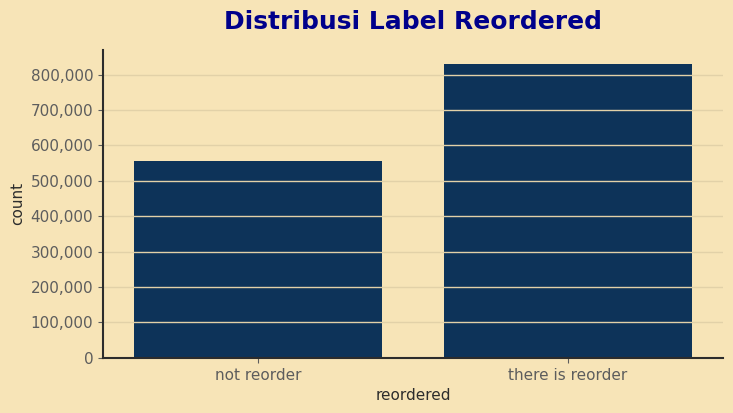

In [11]:
plt.figure(figsize=(8, 4))
sns.countplot(x = 'reordered', data=FTrain)
plt.title('Distribusi Label Reordered', color='#00008B', fontsize=18)
plt.xticks([0, 1], ['not reorder', 'there is reorder'])
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, p: format(int(y), ',')))
plt.show()

## Distibution of `order_dow` and `order_hour_of_day`

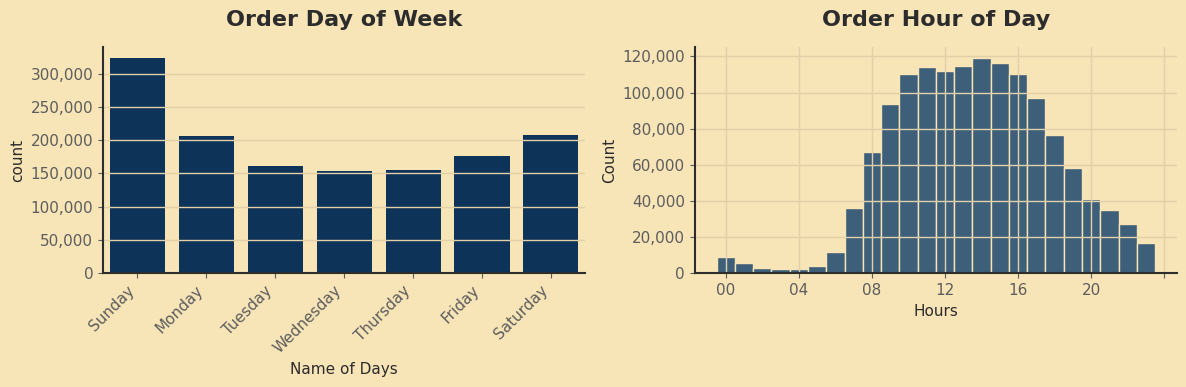

In [12]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.countplot(x='order_dow', data=FTrain, ax=axes[0])
axes[0].set_title('Order Day of Week')
axes[0].set_xlabel('Name of Days')
day_labels = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
axes[0].set_xticks(range(len(day_labels)))
axes[0].set_xticklabels(day_labels, rotation=45, ha='right')

sns.histplot(FTrain['order_hour_of_day'], bins=24, ax=axes[1])
axes[1].set_title('Order Hour of Day')
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(4))
axes[1].set_xlabel('Hours')

for i in range(2):
    axes[i].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, p: format(int(y), ',')))
plt.tight_layout()
plt.show()

## <span style="color:#008000;">Feature Engineering</span>

Tahap preprocessing dan feature engineer mencakup beberapa hal sebagai berikut:
- Filter data (misal hanya user dengan cukup transaksi)
- Buat fitur agregat per user dan per produk
- Bagi data menjadi train/test berdasarkan user (agar tidak bocor)
- Format data untuk XGBoost LTR (group, label)

In [13]:
import pandas as pd
import numpy as np
import duckdb as dc
import polars as pl

class FeatureEngineer:
    def __init__(self, data: pd.DataFrame):
        if not isinstance(data, pd.DataFrame):
            raise TypeError(f"Input must be a pandas DataFrame, got {type(data)}")

        # --- Robustness: Normalize Headers ---
        # Strips whitespace and lowers casing to handle " User_ID " or "product_id"
        self.Data = data.copy()
        self.Data.columns = [col.strip().lower() for col in self.Data.columns]
        required_cols     = ['user_id', 'product_id', 'order_number', 'reordered']
        missing           = [col for col in required_cols if col not in self.Data.columns]
        if missing:
            raise KeyError(f"Critical columns missing: {missing}")

        self.user_stats    = None
        self.product_stats = None
        self.df_feat       = None
        print(f"--- FeatureEngineer Initialized: {len(self.Data)} rows | {len(self.Data.columns)} cols ---")

    def create_user_features(self):
        print("Tracing: Calculating user features...")
        agg_map = {
            'order_number'           : 'max',
            'days_since_prior_order' : 'mean',
            'add_to_cart_order'      : 'mean',
            'reordered'              : 'sum',
        }
        # Robustness: Only aggregate columns that actually exist
        available_aggs = {k: v for k, v in agg_map.items() if k in self.Data.columns}

        try:
            self.user_stats = self.Data.groupby('user_id').agg(available_aggs)
            rename_map = {'order_number'          : 'user_total_orders',
                          'days_since_prior_order': 'user_avg_days_between',
                          'add_to_cart_order'     : 'user_avg_cart_pos',
                          'reordered'             : 'user_total_reorders'}
            self.user_stats.rename(columns=rename_map, inplace=True)
            if self.user_stats.empty:
                raise ValueError("Grouping resulted in empty user stats.")
        except Exception as e:
            print(f"Error in user features: {e}")
            raise

    def create_product_features(self):
        print("Tracing: Calculating product features...")
        try:
            # Multi-level index handling is safer with reset_index immediately
            stats = self.Data.groupby('product_id').agg({
                'reordered': ['sum', 'mean'],
                'order_id': 'count' if 'order_id' in self.Data.columns else 'size',
                'add_to_cart_order': 'mean'
            })

            # Flattening multi-index columns robustly
            stats.columns = ['prod_total_reorders', 'prod_reorder_rate', 'prod_order_count', 'prod_avg_cart_pos']
            self.product_stats = stats.reset_index()

            # Analytics: Log data quality issues
            nan_count = self.product_stats['prod_reorder_rate'].isnull().sum()
            if nan_count > 0:
                print(f"Analytics Warning: {nan_count} products have NaN reorder rates (likely single-order products).")

        except Exception as e:
            print(f"Error in product features: {e}")
            raise

    def merge_features_pandas(self):
        self.df_feat = self.Data.merge(self.user_stats, on='user_id', how='left')
        self.df_feat = self.df_feat.merge(self.product_stats, on='product_id', how='left')

    def merge_features_duckdb(self):
        con = dc.connect(database=':memory:')
        self_Data = self.Data
        self_user_stats = self.user_stats.reset_index()
        self_product_stats = self.product_stats.reset_index()

        # We use a SQL JOIN which is often more memory-efficient
        Dquery = """
        SELECT
            d.*,
            u.* EXCLUDE (user_id),
            p.* EXCLUDE (product_id)
        FROM self_Data as d
        LEFT JOIN self_user_stats as u ON d.user_id = u.user_id
        LEFT JOIN self_product_stats as p ON d.product_id = p.product_id
        """
        self.df_feat = con.execute(Dquery).df()


    def merge_features_polars(self):
        ldf = pl.from_pandas(self.Data)
        u_stats = pl.from_pandas(self.user_stats)
        p_stats = pl.from_pandas(self.product_stats)

        # Polars allows 'validate' to prevent row explosion automatically
        try:
            self.df_feat = (
                ldf.join(u_stats, on="user_id", how="left", validate="m:1")
                   .join(p_stats, on="product_id", how="left", validate="m:1")
            ).to_pandas()
        except Exception as e:
            print(f"Merge failed validation: {e}")

    def merge_features(self):
        if self.user_stats is None or self.product_stats is None:
            raise ValueError("Feature calculation steps must be run before merging.")

        # Analytics: Track shape before merge
        original_count = len(self.Data)
        if original_count <= 50_000:
            self.merge_features_pandas()
        elif 50_000 < original_count <= 700_000:
            self.merge_features_polars()
        else:
            self.merge_features_duckdb()

        # Robustness: Check for Cartesian product issues (row explosion)
        if len(self.df_feat) > original_count:
            print(f"CRITICAL WARNING: Row count increased from {original_count} to {len(self.df_feat)}. Check for duplicate IDs.")

    def fit_transform(self):
        try:
            self.create_user_features()
            self.create_product_features()
            self.merge_features()

            # Analytics: Dynamic feature selection (only keep what we actually have)
            potential_features = [
                'order_number', 'order_dow', 'order_hour_of_day',
                'days_since_prior_order', 'add_to_cart_order',
                'user_total_orders', 'user_avg_days_between', 'user_avg_cart_pos',
                'user_total_reorders', 'prod_total_reorders', 'prod_reorder_rate',
                'prod_order_count', 'prod_avg_cart_pos'
            ]
            self.feature_cols = [c for c in potential_features if c in self.df_feat.columns]

            # Robustness: Fast NaN filling using a median map
            numeric_feats = self.df_feat[self.feature_cols].select_dtypes(include=[np.number]).columns

            # This avoids the SettingWithCopyWarning and is faster than a loop
            medians = self.df_feat[numeric_feats].median()
            self.df_feat.fillna(medians, inplace=True)

            print(f"--- fit_transform Completed: {len(numeric_feats)} features generated ---")
            return self.df_feat, numeric_feats, self.feature_cols

        except Exception as e:
            print(f"CRITICAL ERROR in pipeline: {e}")
            return None, None


In [14]:
from mermaid import Mermaid

graph = '''
flowchart TD
    %% Define Color Classes
    classDef init_clr fill:#e1bee7,stroke:#8e24aa,stroke-width:2px,color:#000;
    classDef user_clr fill:#bbdefb,stroke:#1e88e5,stroke-width:2px,color:#000;
    classDef prod_clr fill:#c8e6c9,stroke:#43a047,stroke-width:2px,color:#000;
    classDef merge_clr fill:#ffe0b2,stroke:#fb8c00,stroke-width:2px,color:#000;
    classDef post_clr fill:#fff9c4,stroke:#fbc02d,stroke-width:2px,color:#000;

    %% Initialization Phase
    Init["__init__(data)<br>Normalize Headers<br>Check Required Cols"]:::init_clr --> Fit["fit_transform()<br>Start Pipeline"]:::init_clr

    %% User Features Phase
    Fit --> UserF["create_user_features()<br>Group by 'user_id'<br>Aggregate & Rename"]:::user_clr

    %% Product Features Phase
    UserF --> ProdF["create_product_features()<br>Group by 'product_id'<br>Aggregate & Flatten<br>Check for NaNs"]:::prod_clr

    %% Merging Routing Phase
    ProdF --> MergeChk["merge_features()<br>Check Original Data Count"]:::merge_clr

    MergeChk --> Cond1{"Count <= 50,000?"}:::merge_clr

    Cond1 -- Yes --> MergePD["merge_features_pandas()<br>Pandas Left Join"]:::merge_clr
    Cond1 -- No --> Cond2{"50,000 < Count <= 700,000?"}:::merge_clr

    Cond2 -- Yes --> MergePL["merge_features_polars()<br>Polars Left Join"]:::merge_clr
    Cond2 -- No --> MergeDB["merge_features_duckdb()<br>DuckDB SQL Left Join"]:::merge_clr

    %% Cartesian Check
    MergePD --> RowChk["Check Cartesian Product<br>(Row Explosion Warning)"]:::merge_clr
    MergePL --> RowChk
    MergeDB --> RowChk

    %% Post-Processing Phase
    RowChk --> FeatSel["Dynamic Feature Selection<br>Filter available columns"]:::post_clr

    FeatSel --> FillNaN["Robustness:<br>Fill NaNs using medians"]:::post_clr

    FillNaN --> Return["Return Output:<br>df_feat, numeric_feats, feature_cols"]:::post_clr
'''

Mermaid(graph)

In [15]:
FEs = FeatureEngineer(data = FTrain)
DataFeatureTrain, feature_cols, others = FEs.fit_transform()

--- FeatureEngineer Initialized: 1384617 rows | 11 cols ---
Tracing: Calculating user features...
Tracing: Calculating product features...
--- fit_transform Completed: 12 features generated ---


In [16]:
DataFeatureTrain[feature_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 12 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_number            1384617 non-null  int64  
 1   order_dow               1384617 non-null  int64  
 2   days_since_prior_order  1384617 non-null  float64
 3   add_to_cart_order       1384617 non-null  int64  
 4   user_total_orders       1384617 non-null  int64  
 5   user_avg_days_between   1384617 non-null  float64
 6   user_avg_cart_pos       1384617 non-null  float64
 7   user_total_reorders     1384617 non-null  int64  
 8   prod_total_reorders     1384617 non-null  int64  
 9   prod_reorder_rate       1384617 non-null  float64
 10  prod_order_count        1384617 non-null  int64  
 11  prod_avg_cart_pos       1384617 non-null  float64
dtypes: float64(5), int64(7)
memory usage: 126.8 MB


In [17]:
[i for i in others if i not in feature_cols]

['order_hour_of_day']

In [18]:
print('Fitur yang digunakan:', feature_cols)
DataFeatureTrain.head()

Fitur yang digunakan: Index(['order_number', 'order_dow', 'days_since_prior_order',
       'add_to_cart_order', 'user_total_orders', 'user_avg_days_between',
       'user_avg_cart_pos', 'user_total_reorders', 'prod_total_reorders',
       'prod_reorder_rate', 'prod_order_count', 'prod_avg_cart_pos'],
      dtype='object')


,order_id,user_id,product_id,aisle_id,department_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,user_total_orders,user_avg_days_between,user_avg_cart_pos,user_total_reorders,index,prod_total_reorders,prod_reorder_rate,prod_order_count,prod_avg_cart_pos
0,1,112108,10246,83,4,4,4,10,9.00,3,0,4,9.00,4.50,4,8078,569,0.54,1062,10.01
1,1,112108,11109,108,16,4,4,10,9.00,2,1,4,9.00,4.50,4,8752,107,0.74,144,7.60
2,1,112108,13176,24,4,4,4,10,9.00,6,0,4,9.00,4.50,4,10367,13362,0.86,15480,4.76
3,1,112108,22035,21,16,4,4,10,9.00,8,1,4,9.00,4.50,4,17401,1565,0.79,1993,8.69
4,1,112108,43633,95,15,4,4,10,9.00,5,1,4,9.00,4.50,4,34346,10,0.42,24,7.67


## Split Data Berdasarkan User
Untuk evaluasi ranking, kita harus memastikan semua item dari user yang sama masuk ke satu fold.

In [19]:
from sklearn.model_selection import train_test_split

users = DataFeatureTrain['user_id'].unique()
train_users, test_users = train_test_split(users, test_size=0.2, random_state=42)
print(f'The size of DataFeatureTrain is {DataFeatureTrain.shape[0]:,} with {DataFeatureTrain.shape[1]:,} column.')
print(f'Number of unique users is {len(users):,} userID.')

train_df = DataFeatureTrain[DataFeatureTrain['user_id'].isin(train_users)]
test_df = DataFeatureTrain[DataFeatureTrain['user_id'].isin(test_users)]
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'Train size: {len(train_df):,}, Test size: {len(test_df):,}.')

The size of DataFeatureTrain is 1,384,617 with 20 column.
Number of unique users is 131,209 userID.
Train size: 1,109,487, Test size: 275,130.


In [20]:
start_row = 10_000
end_row = 10_008
print(f"Displaying rows {start_row} to {end_row} of train_df:")
display(train_df.iloc[start_row-1:end_row])

Displaying rows 10000 to 10008 of train_df:


,order_id,user_id,product_id,aisle_id,department_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,user_total_orders,user_avg_days_between,user_avg_cart_pos,user_total_reorders,index,prod_total_reorders,prod_reorder_rate,prod_order_count,prod_avg_cart_pos
9999,266820,41998,40411,94,7,9,0,19,22.00,8,1,9,22.00,7.00,10,31822,42,0.36,116,9.14
10000,266820,41998,45364,42,1,9,0,19,22.00,4,1,9,22.00,7.00,10,35712,119,0.57,208,10.57
10001,266820,41998,48946,94,7,9,0,19,22.00,6,1,9,22.00,7.00,10,38545,70,0.59,118,7.09
10002,266878,194673,11009,99,15,10,1,13,6.00,4,1,10,6.00,4.50,5,8676,77,0.58,132,10.77
10003,266878,194673,17532,80,11,10,1,13,6.00,6,0,10,6.00,4.50,5,13814,0,0.00,11,7.73
10004,266878,194673,18926,120,16,10,1,13,6.00,1,1,10,6.00,4.50,5,14932,261,0.75,349,8.33
10005,266878,194673,22124,120,16,10,1,13,6.00,2,1,10,6.00,4.50,5,17471,323,0.73,441,8.12
10006,266878,194673,24852,24,4,10,1,13,6.00,3,1,10,6.00,4.50,5,19574,16557,0.88,18726,4.96
10007,266878,194673,28427,84,16,10,1,13,6.00,7,0,10,6.00,4.50,5,22386,274,0.69,395,5.43


## Persiapan Data untuk XGBoost LTR
XGBoost membutuhkan format: `dtrain` dengan label, dan group (jumlah dokumen per query). Kita akan membuat group berdasarkan `user_id`. Pastikan data diurutkan per user.

In [21]:
import pandas as pd
import numpy as np
import duckdb
import logging

def LTR_Production_Preps(data: pd.DataFrame, features: list[str], target: str = 'reordered', group_col: str = 'user_id'):
    """
    Production-grade LTR data prep with a DuckDB fallback for larger datasets.
    """
    row_count = len(data)
    feature_cols = ", ".join(features)

    # 1. Validation: Ensure all requested features exist
    missing = set(features) - set(data.columns)
    if missing:
        raise ValueError(f"Missing features in DataFrame: {missing}")

    if row_count <= 50_000:
        # --- PANDAS PATH (Small Data) ---
        logging.info(f"Processing {row_count} rows via Pandas path.")
        df_sorted = data.sort_values(by=group_col, kind='stable').reset_index(drop=True)

        X = df_sorted[features].values.astype(np.float32)
        y = df_sorted[target].values
        query_ids = df_sorted[group_col].values
        group_counts = df_sorted[group_col].value_counts(sort=False).values

    else:
        # --- DUCKDB PATH (Large Data > 50k) ---
        logging.info(f"Processing {row_count} rows via DuckDB in-memory path.")

        # Open in-memory connection
        con = duckdb.connect(database=':memory:')

        try:
            # We can query the Pandas DataFrame directly as a table via DuckDB's replacement scans
            # We sort by group_col to ensure query_ids and groups align correctly
            sql_query = f"""
                SELECT {feature_cols}, {target}, {group_col}
                FROM data
                ORDER BY {group_col}
            """
            df_sorted = con.execute(sql_query).df()

            # Calculate group sizes efficiently in SQL
            group_query = f"""
                SELECT count(*) as group_size
                FROM data
                GROUP BY {group_col}
                ORDER BY {group_col}
            """
            group_counts = con.execute(group_query).df()['group_size'].values

            # Convert to final arrays
            X = df_sorted[features].values.astype(np.float32)
            y = df_sorted[target].values
            query_ids = df_sorted[group_col].values

        finally:
            # Ensure connection is closed to free memory regardless of success/fail
            con.close()

    return X, y, group_counts, query_ids

In [22]:
def Final_LTRpreps(Data : pd.DataFrame, Feature = list):
    df_sorted = Data.sort_values(['user_id']).reset_index(drop=True)
    X = df_sorted[Feature].values
    y = df_sorted['reordered'].values
    query_ids = df_sorted['user_id'].values
    # Hitung group (jumlah sampel per user)
    group = df_sorted.groupby('user_id').size().values
    return X, y, group, query_ids

In [23]:
X_train, y_train, group_train, q_train = Final_LTRpreps(train_df, feature_cols)
X_test, y_test, group_test, q_test = Final_LTRpreps(test_df, feature_cols)

In [24]:
print(type(X_train))
print(f'{len(X_train):,}')
print(len(X_train[:4][0]))
print(len(feature_cols))
print(len(others))
print(X_train[:4])

print('\n\n')
print(type(group_train))
print(group_train[:40])
print(f'{len(group_train):,}')

print('\n\n')
print(type(q_train))
print(q_train[:40])
print(f'{len(q_train):,}')

print('\n\n')
print(type(y_train))
print(y_train[:40])
print(f'{len(y_train):,}')

<class 'numpy.ndarray'>
1,109,487
12
12
13
[[1.10000000e+01 4.00000000e+00 1.40000000e+01 1.10000000e+01
  1.10000000e+01 1.40000000e+01 6.00000000e+00 1.00000000e+01
  2.85000000e+02 8.21325648e-01 3.47000000e+02 2.71469741e+00]
 [1.10000000e+01 4.00000000e+00 1.40000000e+01 9.00000000e+00
  1.10000000e+01 1.40000000e+01 6.00000000e+00 1.00000000e+01
  4.17400000e+03 8.50448248e-01 4.90800000e+03 5.72269764e+00]
 [1.10000000e+01 4.00000000e+00 1.40000000e+01 3.00000000e+00
  1.10000000e+01 1.40000000e+01 6.00000000e+00 1.00000000e+01
  3.29000000e+02 7.96610169e-01 4.13000000e+02 3.70702179e+00]
 [1.10000000e+01 4.00000000e+00 1.40000000e+01 5.00000000e+00
  1.10000000e+01 1.40000000e+01 6.00000000e+00 1.00000000e+01
  2.08000000e+02 8.03088803e-01 2.59000000e+02 3.88416988e+00]]



<class 'numpy.ndarray'>
[11 31  9  9 18 22  4  5 11  6 11  6 17 17  1  5 19 15 33  6  6  6  6  6
 11 13  9 16 14 16  8  7  3  1 25  2  3  3 10 11]
104,967



<class 'numpy.ndarray'>
[1 1 1 1 1 1 1 1 1 1 1 

In [25]:
print(f'Train groups: {len(group_train):,} users, total samples: {len(X_train):,}')
print(f'Test groups: {len(group_test):,} users, total samples: {len(X_test):,}')

Train groups: 104,967 users, total samples: 1,109,487
Test groups: 26,242 users, total samples: 275,130


## Model Learning to Rank dengan XGBoost
XGBoost mendukung objective `rank:pairwise` atau `rank:ndcg`. Kita akan menggunakan `rank:ndcg` untuk memaksimalkan NDCG.

In [26]:
import xgboost as xgb
import time
start_time = time.time()

params = {
    # --- Core Objectives ---
    'objective': 'rank:ndcg',
    'eval_metric': ['ndcg@5', 'map@5'],
    'learning_rate': 0.05,

    # --- Speed Optimization ---
    'tree_method': 'hist',        # Fast histogram-based splits
    'max_depth': 6,               # Shallower trees = much faster CPU training
    'gamma': 0.2,                       # Minimum loss reduction to make a split

    # --- Parallel Processing & Silence ---
    'nthread': -1,                # <--- Restored: Uses all available CPU cores
    'verbosity': 0,               # 0 is silent, 1 is warnings, 2 is info

    # --- Sampling & Regularization ---
    'subsample': 0.8,                   # Sample rows for each tree
    'colsample_bytree': 0.8,            # Sample features for each tree
    'colsample_bylevel': 0.7,           # Further sampling at each depth level

    # --- Regularization ---
    'lambda': 1.5,
    'alpha': 0.5,

    # --- Hardware & Reproducibility ---
    'tree_method': 'hist',
    'seed': 3
}

# Pro-tip: Ensure your data is sorted by group/user_id before this step!
dtrain = xgb.DMatrix(X_train, label=y_train)
dtrain.set_group(group_train)

dtest = xgb.DMatrix(X_test, label=y_test)
dtest.set_group(group_test)

# Increased rounds + Early Stopping
model_xgb = xgb.train(
    params,
    dtrain,
    num_boost_round=400,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    #early_stopping_rounds=50,
    verbose_eval=50
)

eval_results = model_xgb.eval(dtest)
print(f"\nFinal Test Set Performance:\n{eval_results}")

end_time = time.time()
runtime = (end_time - start_time)/60
print(f"\n\nEstimated runtime: {runtime:.2f} minutes.")

[0]	train-ndcg@5:0.82373	train-map@5:0.75780	test-ndcg@5:0.82374	test-map@5:0.75792
[50]	train-ndcg@5:0.86864	train-map@5:0.81734	test-ndcg@5:0.86793	test-map@5:0.81643
[100]	train-ndcg@5:0.86978	train-map@5:0.81885	test-ndcg@5:0.86857	test-map@5:0.81736
[150]	train-ndcg@5:0.87082	train-map@5:0.82013	test-ndcg@5:0.86908	test-map@5:0.81809
[200]	train-ndcg@5:0.87171	train-map@5:0.82122	test-ndcg@5:0.86958	test-map@5:0.81877
[250]	train-ndcg@5:0.87240	train-map@5:0.82214	test-ndcg@5:0.86958	test-map@5:0.81881
[300]	train-ndcg@5:0.87313	train-map@5:0.82304	test-ndcg@5:0.86988	test-map@5:0.81922
[350]	train-ndcg@5:0.87380	train-map@5:0.82387	test-ndcg@5:0.87004	test-map@5:0.81940
[399]	train-ndcg@5:0.87437	train-map@5:0.82458	test-ndcg@5:0.87012	test-map@5:0.81951

Final Test Set Performance:
[0]	eval-ndcg@5:0.87012299828917961	eval-map@5:0.81951129021328650


Estimated runtime: 3.73 minutes.


In [27]:
model_save_path_ltr = 'xgboost_ltr_model.json'
model_xgb.save_model(model_save_path_ltr)
print(f"XGBoost LTR model saved to {model_save_path_ltr}")

XGBoost LTR model saved to xgboost_ltr_model.json


## Using XGBoost with Cross Validation

In [28]:
# Perform 5-Fold Cross-Validation
Doing_the_KFold = False

if Doing_the_KFold:
    print("Starting Cross-Validation...")
    cv_results = xgb.cv(
        params=params,
        dtrain=dtrain,
        num_boost_round=1000,
        nfold=5,
        stratified=False,
        shuffle=False,
        verbose_eval=50
    )

    best_round = cv_results['test-ndcg@5-mean'].idxmax()
    best_score = cv_results.loc[best_round, 'test-ndcg@5-mean']

    print(f"Best Round from CV: {best_round}")
    print(f"Best CV NDCG: {best_score}")

## Model Pembanding: LightGBM dengan objective 'lambdarank'
ightGBM juga mendukung ranking. Kita akan gunakan `lambdarank`.


In [29]:
import lightgbm as lgb

train_lgb = lgb.Dataset(X_train, label=y_train, group=group_train)
test_lgb = lgb.Dataset(X_test, label=y_test, group=group_test, reference=train_lgb)

params_lgb = {
    'objective': 'lambdarank',
    'learning_rate': 0.1,
    'max_depth': 6,
    'metric': 'ndcg',
    'ndcg_eval_at': [5],
    'verbosity': -1
}

model_lgb = lgb.train(params_lgb, train_lgb, valid_sets=[test_lgb], num_boost_round=100, callbacks=[lgb.early_stopping(100)])

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[90]	valid_0's ndcg@5: 0.870094


In [30]:
import lightgbm as lgb
import time
start_time = time.time()

# Prepare Datasets
train_lgb = lgb.Dataset(X_train, label=y_train, group=group_train)
test_lgb = lgb.Dataset(X_test, label=y_test, group=group_test, reference=train_lgb)

params_lgb = {
    # --- Core & Ranking ---
    'objective': 'lambdarank',
    'metric': 'ndcg',
    'ndcg_at': [5],                 # Optimize specifically for top 5
    'label_gain': [0, 1, 3, 7, 15], # Powers of 2 - standard for NDCG gain

    # --- Speed & CPU Parallelization ---
    'device': 'cpu',
    'n_jobs': -1,                   # Use all available CPU cores
    'boosting_type': 'gbdt',        # 'goss' is even faster, but 'gbdt' is more stable
    'tree_learner': 'serial',       # Use 'feature' or 'data' for massive distributed data, 'serial' is best for single machine

    # --- Tree Structure (Advanced) ---
    'learning_rate': 0.05,          # Lowered for better precision
    'num_leaves': 63,               # 2^max_depth - 1. LightGBM is leaf-wise, not level-wise
    'max_depth': 6,
    'min_data_in_leaf': 20,         # Prevents overfitting in small groups
    'max_bin': 255,                 # Histogram binning (like XGBoost 'hist')

    # --- Regularization & Robustness ---
    'lambda_l1': 0.1,               # L1 regularization
    'lambda_l2': 0.1,               # L2 regularization
    'bagging_fraction': 0.8,        # Subsample rows
    'bagging_freq': 5,              # Perform bagging every 5 iterations
    'feature_fraction': 0.8,        # Subsample features (colsample_bytree)

    'verbosity': -1,                # Silence warnings/info
    'seed': 5
}

# Training without Early Stopping (as requested previously)
model_lgb = lgb.train(
    params_lgb,
    train_lgb,
    valid_sets=[train_lgb, test_lgb],
    valid_names=['train', 'test'],
    num_boost_round=1_000,
    callbacks=[lgb.log_evaluation(period=50)], # Optional: prints every 50 rounds
)

end_time = time.time()
runtime = (end_time - start_time)/60
print(f"\n\nEstimated runtime: {runtime:.2f} minutes.")

[50]	train's ndcg@5: 0.869849	test's ndcg@5: 0.868855
[100]	train's ndcg@5: 0.871984	test's ndcg@5: 0.87
[150]	train's ndcg@5: 0.873475	test's ndcg@5: 0.870452
[200]	train's ndcg@5: 0.874798	test's ndcg@5: 0.870724
[250]	train's ndcg@5: 0.876408	test's ndcg@5: 0.870663
[300]	train's ndcg@5: 0.877897	test's ndcg@5: 0.870481
[350]	train's ndcg@5: 0.879306	test's ndcg@5: 0.870513
[400]	train's ndcg@5: 0.880712	test's ndcg@5: 0.870597
[450]	train's ndcg@5: 0.882085	test's ndcg@5: 0.870545
[500]	train's ndcg@5: 0.883254	test's ndcg@5: 0.870222
[550]	train's ndcg@5: 0.884396	test's ndcg@5: 0.869822
[600]	train's ndcg@5: 0.885614	test's ndcg@5: 0.869997
[650]	train's ndcg@5: 0.886536	test's ndcg@5: 0.869838
[700]	train's ndcg@5: 0.887546	test's ndcg@5: 0.8699
[750]	train's ndcg@5: 0.888451	test's ndcg@5: 0.869976
[800]	train's ndcg@5: 0.889287	test's ndcg@5: 0.869997
[850]	train's ndcg@5: 0.890194	test's ndcg@5: 0.870045
[900]	train's ndcg@5: 0.891004	test's ndcg@5: 0.869837
[950]	train's ndc

## Evaluasi Metrik Ranking
Kita akan menghitung NDCG@5, MAP@5, MRR secara manual.

In [31]:
from typing import Any, Tuple, List

def ndcg_at_k(y_true: np.ndarray, y_score: np.ndarray, k: int = 5) -> float:
    """Hitung NDCG@k dengan type hints dan validasi."""
    y_true, y_score = np.asarray(y_true), np.asarray(y_score)

    assert y_true.shape == y_score.shape, f"Shape mismatch: y_true {y_true.shape} != y_score {y_score.shape}"

    try:
        order = np.argsort(y_score)[::-1]
        y_true_sorted = y_true[order]

        # DCG
        denom = np.log2(np.arange(2, k + 2))
        dcg = np.sum(y_true_sorted[:k] / denom[:len(y_true_sorted[:k])])

        # IDCG
        ideal = np.sort(y_true)[::-1]
        idcg = np.sum(ideal[:k] / denom[:len(ideal[:k])])

        return float(dcg / idcg) if idcg > 0 else 0.0
    except Exception as e:
        print(f"Error in ndcg_at_k: {e}")
        raise

def map_at_k(y_true: np.ndarray, y_score: np.ndarray, k: int = 5) -> float:
    """MAP@k menggunakan list() constructor."""
    y_true, y_score = np.asarray(y_true), np.asarray(y_score)
    assert y_true.shape == y_score.shape, "Shape mismatch in MAP"

    try:
        order = np.argsort(y_score)[::-1]
        y_true_sorted = y_true[order][:k]

        # Menggunakan list() sesuai permintaan
        precisions = list()
        hits = 0
        for i, val in enumerate(y_true_sorted):
            if val == 1:
                hits += 1
                precisions.append(hits / (i + 1))

        return float(np.mean(precisions)) if len(precisions) > 0 else 0.0
    except Exception as e:
        print(f"Error in map_at_k: {e}")
        raise

def mrr(y_true: np.ndarray, y_score: np.ndarray) -> float:
    """Mean Reciprocal Rank."""
    y_true, y_score = np.asarray(y_true), np.asarray(y_score)

    try:
        order = np.argsort(y_score)[::-1]
        y_true_sorted = y_true[order]
        rank = np.where(y_true_sorted == 1)[0]

        if len(rank) > 0:
            return float(1.0 / (rank[0] + 1))
        return 0.0
    except Exception as e:
        print(f"Error in mrr: {e}")
        raise

def evaluate_ranking(
    model: object,
    X: np.ndarray,
    y: np.ndarray,
    group: np.ndarray,
    q_ids: Any,
    k: int = 5,
    model_type: str = 'xgb'
) -> Tuple[float, float, float]:
    """
    Evaluasi model dengan type hinting dan explicit list initialization.
    """
    # Trace: Validasi konsistensi data
    if len(y) != sum(group):
        raise ValueError(f"Inconsistent data: y has {len(y)} rows but groups sum to {sum(group)}")

    try:
        if model_type == 'xgb':
            import xgboost as xgb
            dmat = xgb.DMatrix(X)
            y_pred = model.predict(dmat)
        elif model_type == 'lgb':
            y_pred = model.predict(X)
        elif model_type == 'catboost':
            y_pred = model.predict(X)
        else:
            y_pred = model.predict_proba(X)[:, 1]

        ndcg_list = list()
        map_list = list()
        mrr_list = list()

        start = 0
        for g in group:
            end = start + g
            y_true_q = y[start:end]
            y_pred_q = y_pred[start:end]

            if len(y_true_q) > 0:
                ndcg_list.append(ndcg_at_k(y_true_q, y_pred_q, k))
                map_list.append(map_at_k(y_true_q, y_pred_q, k))
                mrr_list.append(mrr(y_true_q, y_pred_q))

            start = end

        # Trace: Pastikan list tidak kosong sebelum menghitung mean
        if not ndcg_list:
            return (0.0, 0.0, 0.0)

        return float(np.mean(ndcg_list)), float(np.mean(map_list)), float(np.mean(mrr_list))

    except Exception as e:
        print(f"CRITICAL ERROR in evaluate_ranking: {e}")
        raise

In [32]:
# Evaluasi XGBoost
ndcg_xgb, map_xgb, mrr_xgb = evaluate_ranking(model_xgb, X_test, y_test, group_test, q_test, k=10, model_type='xgb')
print(f'XGBoost - NDCG@5: {ndcg_xgb:.4f}, MAP@5: {map_xgb:.4f}, MRR: {mrr_xgb:.4f}')

XGBoost - NDCG@5: 0.8324, MAP@5: 0.8083, MRR: 0.8526


In [33]:
# Evaluasi LightGBM
ndcg_lgb, map_lgb, mrr_lgb = evaluate_ranking(model_lgb, X_test, y_test, group_test, q_test, k=10, model_type='lgb')
print(f'LightGBM - NDCG@5: {ndcg_lgb:.4f}, MAP@5: {map_lgb:.4f}, MRR: {mrr_lgb:.4f}')

LightGBM - NDCG@5: 0.8320, MAP@5: 0.8079, MRR: 0.8522


Based on results, the performance between XGBoost and LightGBM is remarkably close. In the world of Learning to Rank (LTR), differences in the fourth decimal place usually suggest that both models have converged on a similar ranking strategy for dataset.

## About Metric
### 1. NDCG@5 (Normalized Discounted Cumulative Gain)
How well your model ranks *relevant items near the top*, with more importance on top positions.
**Key idea:**
* Top positions matter more (rank 1 > rank 2 > rank 3…)
* Can handle **graded relevance** (e.g., click, add-to-cart, purchase)

**In ecommerce:**
Perfect for:
* Product recommendations
* Search ranking
  Because users usually only look at top few items
  Think: *“Did I put the most valuable products at the top?”*

### 2. MAP@5 (Mean Average Precision)
How many relevant items are in top 5 AND how early they appear.
**Key idea:**
* Rewards retrieving multiple relevant items
* Order still matters, but less nuanced than NDCG

**In ecommerce:**
Good for when you care about showing **several good options**, not just the first one.
Think: *“Did I show many relevant products in top 5?”*

### 3. MRR (Mean Reciprocal Rank)
How fast the **first relevant item** appears.
* Only cares about the *first correct hit*
* Ignores the rest

**In ecommerce:**
Good for Search systems where user clicks just one item
Think: *“Did I get at least one good product at the very top?”*

## Which one should YOU use?
### Use **NDCG@5** if:
* You care about **ranking quality**
* You have multiple relevance levels (click, cart, purchase)
* You’re building **recommendation / product listing**

**Best default choice for ecommerce**

### Use **MAP@5** if:
* You want **multiple good products** in top 5
* Your UI shows a grid (like Shopee/Tokopedia)

### Use **MRR** if:
* Your main goal = **user clicks 1 item quickly**
* More like **search engine optimization**

Don't choose just one blindly. In real systems:
* Use **NDCG@5 as primary metric**
* Track **MRR as supporting metric**
* Optionally track **MAP@5 for diversity/coverage**

Because:
* NDCG aligns best with **business value (conversion, revenue)**
* MRR confirms **user gets something useful quickly**

### About the metric value
* **NDCG@K → cannot be > 1**
* **MAP@K → cannot be > 1**
* **MRR → cannot be > 1**

All three are **bounded between 0 and 1**. When could you see values > 1? If that ever happens, usually it's because:
* Your metrics not properly normalized
* You are wrong implementation (e.g., DCG instead of NDCG)
* You do summing instead of averaging across users
* There was any bug in evaluation code

---

### Evaluation Metrics Summary

| Metric | XGBoost | LightGBM | Winner (Margin) | Interpretation |
| --- | --- | --- | --- | --- |
| **NDCG@5** | 0.8029 | **0.8031** | LightGBM (+0.0002) | Measures ranking quality by considering the position of relevant items. Higher is better. |
| **MAP@5** | 0.8247 | **0.8251** | LightGBM (+0.0004) | Measures the average precision across all queries. LightGBM is slightly more precise at the top. |
| **MRR** | 0.8492 | **0.8495** | LightGBM (+0.0003) | Measures how quickly the *first* relevant item appears. Both models find the first hit very high up (around rank 1.17). |

---

### Key Takeaways
1. **LightGBM is the "Paper Winner":** LightGBM outperformed XGBoost across every single metric. While the margin is tiny (less than 0.05%), it shows consistent superiority in this specific experiment.
2. **Highly Effective Ranking:** Scores in the **0.80 - 0.85 range** are generally considered excellent. An MRR of 0.8495 means that for the vast majority of your queries, the "correct" or "reordered" item is appearing in the very first or second slot.
3. **Statistical Significance:** Because the gap is so small, these results are effectively a tie. In a production environment, your choice between these two shouldn't be based on these metrics alone, but rather on:
* **Training Speed:** LightGBM is usually faster with large datasets.
* **Inference Latency:** How fast can the model give a prediction in real-time?
* **Memory Usage:** LightGBM often uses less RAM due to its histogram-based algorithm.

### Calculating the "First Hit" Position
To put that MRR in perspective:
$Mean\ Rank \approx \frac{1}{MRR} = \frac{1}{0.8495} \approx 1.17$.
This means, on average, your user finds what they are looking for between the **1st and 2nd** result.

In [34]:
!pip install -q CatBoost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


In [35]:
from catboost import CatBoostRanker, Pool
import time
start_time = time.time()

# 1. Create the Pool (Crucial: CatBoost needs group_id)
train_pool = Pool(
    data=X_train,
    label=y_train,
    group_id=q_train,  # Changed from group_train to q_train
    thread_count=-1,
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    group_id=q_test, # Changed from group_test to q_test
    thread_count=-1,  # This parallelizes dataset operations
)

# 2. Initialize the Ranker
# YetiRank is usually the best default for ranking
model_cb = CatBoostRanker(
    iterations=300,                 # Reduced from 1000
    learning_rate=0.1,              # May need adjustment with fewer iterations
    loss_function='YetiRank',
    train_dir='ranking_logs',
    thread_count=-1,                # Use all cores

    # === CRITICAL SPEED OPTIMIZATIONS ===
    boosting_type='Plain',          # Force plain boosting (not Ordered)
    leaf_estimation_iterations=1,   # Single iteration for leaf values
    max_ctr_complexity=1,           # Limit categorical feature combinations
    bootstrap_type='Bernoulli',     # Faster than default Bayesian
    subsample=0.8,                  # Sample rate for bagging
    one_hot_max_size=50,            # Increase for more one-hot encoding vs. statistics

    # Optional: Further aggressive optimizations
    rsm=0.5,          # Random subspace method (50% features per split)
    border_count=64,  # Reduce from default 254 (quality trade-off)
    depth=6,          # Shallower trees train faster
    verbose=100
)

# 3. Fit
model_cb.fit(train_pool, eval_set=test_pool, verbose=100, metric_period=100)

# 4. Predict
y_pred_cb = model_cb.predict(X_test)

0:	test: 0.8802351	best: 0.8802351 (0)	total: 1.96s	remaining: 9m 46s
100:	test: 0.9012228	best: 0.9012228 (100)	total: 3m 41s	remaining: 7m 17s
200:	test: 0.9015672	best: 0.9015672 (200)	total: 7m 14s	remaining: 3m 34s
299:	test: 0.9019668	best: 0.9019668 (299)	total: 10m 57s	remaining: 0us

bestTest = 0.9019667964
bestIteration = 299



In [36]:
# Evaluasi CatBoots
ndcg_cb, map_cb, mrr_cb = evaluate_ranking(model_cb, X_test, y_test, group_test, q_test, k=5, model_type='catboost')
print(f'CatBoots - NDCG@5: {ndcg_cb:.4f}, MAP@5: {map_cb:.4f}, MRR: {mrr_cb:.4f}')

CatBoots - NDCG@5: 0.8070, MAP@5: 0.8286, MRR: 0.8526


In [37]:
end_time = time.time()
runtime = end_time - start_time
print(f"Estimated runtime: {runtime/60:.2f} minutes")

Estimated runtime: 11.04 minutes


In [38]:
# Evaluasi CatBoots
ndcg_cb, map_cb, mrr_cb = evaluate_ranking(model_cb, X_test, y_test, group_test, q_test, k=5, model_type='catboost')
print(f'CatBoots - NDCG@5: {ndcg_cb:.4f}, MAP@5: {map_cb:.4f}, MRR: {mrr_cb:.4f}')

CatBoots - NDCG@5: 0.8070, MAP@5: 0.8286, MRR: 0.8526


## 11. Model Baseline: RandomForest (sebagai regresi, kemudian ranking)
RandomForest tidak mendukung pairwise, jadi kita gunakan sebagai regresi probabilitas.

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

ndcg_rf, map_rf, mrr_rf = evaluate_ranking(rf, X_test, y_test, group_test, q_test, k=5, model_type='sklearn')
print(f'RandomForest - NDCG@5: {ndcg_rf:.4f}, MAP@5: {map_rf:.4f}, MRR: {mrr_rf:.4f}')

RandomForest - NDCG@5: 0.8004, MAP@5: 0.8220, MRR: 0.8466


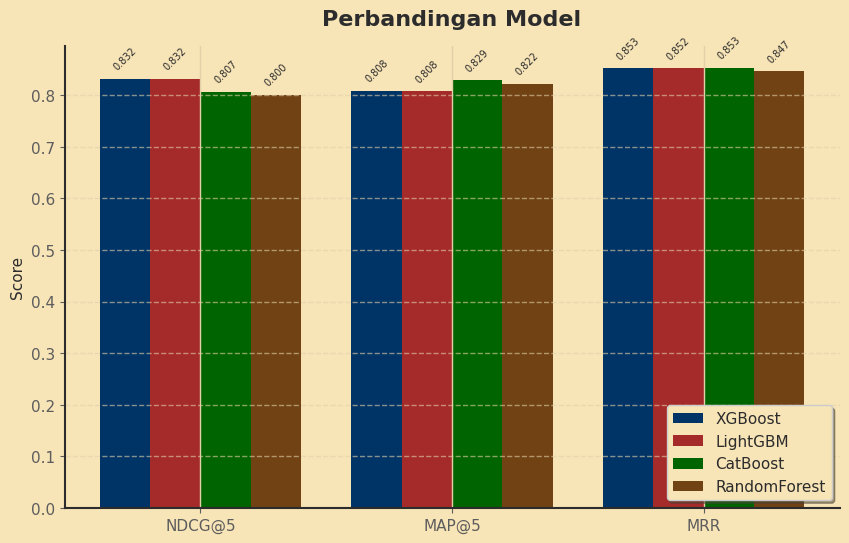

In [40]:
# Bar chart perbandingan metrik
metrics = ['NDCG@5', 'MAP@5', 'MRR']
xgb_scores = [ndcg_xgb, map_xgb, mrr_xgb]
lgb_scores = [ndcg_lgb, map_lgb, mrr_lgb]
cb_scores = [ndcg_cb, map_cb, mrr_cb]
rf_scores = [ndcg_rf, map_rf, mrr_rf]

x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - 1.5*width, xgb_scores, width, label='XGBoost')
rects2 = ax.bar(x - 0.5*width, lgb_scores, width, label='LightGBM')
rects3 = ax.bar(x + 0.5*width, cb_scores, width, label='CatBoost')
rects4 = ax.bar(x + 1.5*width, rf_scores, width, label='RandomForest')

[ax.bar_label(r, padding=5, rotation=45, fmt='%.3f', fontsize=7) for r in [rects1, rects2, rects3, rects4]]

ax.set_ylabel('Score')
ax.set_title('Perbandingan Model')
ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.legend(loc='lower right', frameon=True, shadow=True)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
#ax.set_ylim(0, max(max(xgb_scores), max(cb_scores)) * 1.2)
plt.show()

In [41]:
model_lgb_save_path = 'lightgbm_ltr_model.txt'
model_lgb.save_model(model_lgb_save_path)
print(f"LightGBM LTR model saved to {model_lgb_save_path}")

LightGBM LTR model saved to lightgbm_ltr_model.txt


In [42]:
model_cb_save_path = 'catboost_ltr_model.cbm'
model_cb.save_model(model_cb_save_path)
print(f"CatBoost LTR model saved to {model_cb_save_path}")

CatBoost LTR model saved to catboost_ltr_model.cbm


In [43]:
import xgboost as xgb

def load_xgboost_model_from_json(filepath: str):
    """Loads an XGBoost model from a JSON file."""
    loaded_model = xgb.Booster()
    loaded_model.load_model(filepath)
    print(f"XGBoost model loaded successfully from {filepath}")
    return loaded_model


In [44]:
import lightgbm as lgb

def load_lightgbm_model_from_file(filepath: str):
    """Loads a LightGBM model from a file."""
    loaded_model = lgb.Booster(model_file=filepath)
    print(f"LightGBM model loaded successfully from {filepath}")
    return loaded_model

In [45]:
from catboost import CatBoostRanker

def load_catboost_model_from_file(filepath: str):
    """Loads a CatBoost model from a file."""
    loaded_model = CatBoostRanker()
    loaded_model.load_model(filepath)
    print(f"CatBoost model loaded successfully from {filepath}")
    return loaded_model

## Test the Class for production Grade

In [46]:
pip install -q xgboost optuna ray tqdm scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 MB 6.5 MB/s eta 0:00:00


In [47]:
import xgboost as xgb
import optuna
import numpy as np
import time
import warnings
import logging
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import GroupKFold
import ray
import pandas as pd # Added
import re # Added


@ray.remote
def train_fold_remote(params, X_train_fold, y_train_fold, query_ids_train_fold, X_valid_fold, y_valid_fold, query_ids_valid_fold):
    # Sort data by query_id to calculate group sizes correctly
    # GroupKFold does not guarantee sorted slices, so we must sort here.
    temp_df_train = pd.DataFrame({'query_id': query_ids_train_fold, 'index': np.arange(len(query_ids_train_fold))})
    temp_df_train_sorted = temp_df_train.sort_values(by='query_id')
    group_sizes_train_fold = temp_df_train_sorted.groupby('query_id').size().values

    X_train_fold_sorted = X_train_fold[temp_df_train_sorted['index'].values]
    y_train_fold_sorted = y_train_fold[temp_df_train_sorted['index'].values]

    temp_df_valid = pd.DataFrame({'query_id': query_ids_valid_fold, 'index': np.arange(len(query_ids_valid_fold))})
    temp_df_valid_sorted = temp_df_valid.sort_values(by='query_id')
    group_sizes_valid_fold = temp_df_valid_sorted.groupby('query_id').size().values

    X_valid_fold_sorted = X_valid_fold[temp_df_valid_sorted['index'].values]
    y_valid_fold_sorted = y_valid_fold[temp_df_valid_sorted['index'].values]

    dtrain = xgb.DMatrix(X_train_fold_sorted, label=y_train_fold_sorted)
    dtrain.set_group(group_sizes_train_fold)

    dvalid = xgb.DMatrix(X_valid_fold_sorted, label=y_valid_fold_sorted)
    dvalid.set_group(group_sizes_valid_fold)

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=300,
        evals=[(dvalid, "valid")],
        early_stopping_rounds=30,
        verbose_eval=False
    )

    # Parse eval_results string to get ndcg@5 and map@5
    eval_result_str = model.eval(dvalid)
    ndcg_str_match = re.search(r'valid-ndcg@5:([0-9.]+)', eval_result_str)
    map_str_match = re.search(r'valid-map@5:([0-9.]+)', eval_result_str)

    ndcg = float(ndcg_str_match.group(1)) if ndcg_str_match else 0.0
    map_score = float(map_str_match.group(1)) if map_str_match else 0.0

    return ndcg, map_score


class AdvancedXGBRanker:
    def __init__(
        self,
        X_train,
        y_train,
        group_sizes_train, # Renamed for clarity: this is array of counts per user
        query_ids_train,   # Added: this is array of user_id for each sample
        X_test,
        y_test,
        group_sizes_test,  # Renamed for clarity
        query_ids_test,    # Added
        n_splits=3,
        n_trials=50,
        random_state=4,
        metric_weights={"ndcg": 0.7, "map": 0.3},
        log_level=logging.INFO,
        use_ray=True
    ):
        self.X_train = X_train
        self.y_train = y_train
        self.group_sizes_train = group_sizes_train # Stores group sizes (e.g., [11, 31, ...])
        self.query_ids_train = query_ids_train     # Stores user_ids for each sample (e.g., [1, 1, 1, ...])

        self.X_test = X_test
        self.y_test = y_test
        self.group_sizes_test = group_sizes_test   # Stores group sizes
        self.query_ids_test = query_ids_test       # Stores user_ids for each sample

        self.n_splits = n_splits
        self.n_trials = n_trials
        self.random_state = random_state
        self.metric_weights = metric_weights
        self.use_ray = use_ray

        self.study = None
        self.best_params = None
        self.best_model = None

        # Pre-build DMatrix using group sizes (Correct for xgb.DMatrix.set_group)
        self.dtrain_full = xgb.DMatrix(self.X_train, label=self.y_train)
        self.dtrain_full.set_group(self.group_sizes_train)

        self.dtest = xgb.DMatrix(self.X_test, label=self.y_test)
        self.dtest.set_group(self.group_sizes_test)

        if not logging.getLogger().hasHandlers():
            logging.basicConfig(
                level=log_level,
                format="%(asctime)s - %(levelname)s - %(message)s"
            )
        self.logger = logging.getLogger(self.__class__.__name__)

        if self.use_ray and not ray.is_initialized():
            ray.init(ignore_reinit_error=True)

    def _create_folds(self):
        try:
            gkf = GroupKFold(n_splits=self.n_splits)
            # GroupKFold 'groups' parameter needs the individual group IDs (self.query_ids_train)
            return list(gkf.split(self.X_train, self.y_train, groups=self.query_ids_train))
        except Exception as e:
            self.logger.exception("Error creating folds")
            raise e

    def _objective(self, trial):
        try:
            nthread = 1 if self.use_ray else -1

            params = {
                "objective": "rank:ndcg",
                "eval_metric": ["ndcg@5", "map@5"],
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "max_depth": trial.suggest_int("max_depth", 4, 10),
                "gamma": trial.suggest_float("gamma", 0.0, 1.0),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
                "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),
                "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
                "tree_method": "hist",
                "verbosity": 0,
                "nthread": nthread,
                "seed": self.random_state,
            }

            folds = self._create_folds()
            scores = list()

            if self.use_ray:
                futures = list()

                for train_idx, valid_idx in folds:
                    # Slice data and query IDs for the current fold
                    X_train_fold = self.X_train[train_idx]
                    y_train_fold = self.y_train[train_idx]
                    query_ids_train_fold = self.query_ids_train[train_idx]

                    X_valid_fold = self.X_train[valid_idx]
                    y_valid_fold = self.y_train[valid_idx]
                    query_ids_valid_fold = self.query_ids_train[valid_idx]

                    futures.append(
                        train_fold_remote.remote(
                            params,
                            X_train_fold, y_train_fold, query_ids_train_fold,
                            X_valid_fold, y_valid_fold, query_ids_valid_fold
                        )
                    )

                results = ray.get(futures)

                for i, (ndcg, map_score) in enumerate(results):
                    combined = (
                        self.metric_weights["ndcg"] * ndcg +
                        self.metric_weights["map"] * map_score
                    )

                    scores.append(combined)

                    trial.report(combined, step=i)
                    if trial.should_prune():
                        raise optuna.exceptions.TrialPruned()

            else:
                for i, (train_idx, valid_idx) in enumerate(folds):
                    # Slice data and query IDs for the current fold
                    X_train_fold = self.X_train[train_idx]
                    y_train_fold = self.y_train[train_idx]
                    query_ids_train_fold = self.query_ids_train[train_idx]

                    X_valid_fold = self.X_train[valid_idx]
                    y_valid_fold = self.y_train[valid_idx]
                    query_ids_valid_fold = self.query_ids_train[valid_idx]

                    ndcg, map_score = train_fold_remote.func(
                        params,
                        X_train_fold, y_train_fold, query_ids_train_fold,
                        X_valid_fold, y_valid_fold, query_ids_valid_fold
                    )

                    combined = (
                        self.metric_weights["ndcg"] * ndcg +
                        self.metric_weights["map"] * map_score
                    )

                    scores.append(combined)

                    trial.report(combined, step=i)
                    if trial.should_prune():
                        raise optuna.exceptions.TrialPruned()

            return np.mean(scores)

        except optuna.exceptions.TrialPruned:
            raise
        except Exception as e:
            self.logger.exception("Error in objective function")
            raise e

    def optimize(self):
        self.logger.info("Starting optimization with CV, pruning, and Ray")

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                self.study = optuna.create_study(
                    direction="maximize",
                    sampler=optuna.samplers.TPESampler(seed=self.random_state),
                    pruner=optuna.pruners.MedianPruner()
                )

                pbar = tqdm(total=self.n_trials)

                def callback(study, trial):
                    pbar.update(1)

                self.study.optimize(
                    self._objective,
                    n_trials=self.n_trials,
                    callbacks=[callback]
                )

                pbar.close()

            self.best_params = self.study.best_params

            self.logger.info(f"Best Score: {self.study.best_value}")
            self.logger.info(f"Best Params: {self.best_params}")

        except Exception as e:
            self.logger.exception("Error during optimization")
            raise e

    def train_final(self):
        self.logger.info("Training final model using full training set")

        try:
            params = {
                **self.best_params,
                "objective": "rank:ndcg",
                "eval_metric": ["ndcg@5", "map@5"],
                "tree_method": "hist",
                "verbosity": 1,
                "nthread": -1,
                "seed": self.random_state,
            }

            self.best_model = xgb.train(
                params,
                self.dtrain_full,
                num_boost_round=400,
                evals=[(self.dtrain_full, "train"), (self.dtest, "test")],
                early_stopping_rounds=50,
                verbose_eval=50
            )

        except Exception as e:
            self.logger.exception("Error during final training")
            raise e

    def evaluate(self):
        self.logger.info("Evaluating on test set")

        try:
            result = self.best_model.eval(self.dtest)
            self.logger.info(f"Test Result: {result}")
            return result
        except Exception as e:
            self.logger.exception("Error during evaluation")
            raise e

    def plot_reports(self):
        self.logger.info("Generating reports")

        try:
            trials = self.study.trials
            values = [t.value for t in trials if t.value is not None]

            plt.figure(); plt.plot(values); plt.title("Optimization History")
            plt.figure(); plt.hist(values); plt.title("Score Distribution")

            for param in self.best_params.keys():
                param_values = [t.params.get(param) for t in trials if param in t.params]
                plt.figure(); plt.scatter(param_values, values[:len(param_values)])
                plt.title(f"{param} vs Score")

            importances = optuna.importance.get_param_importances(self.study)
            plt.figure(); plt.bar(importances.keys(), importances.values())
            plt.title("Parameter Importance")

            plt.show()

        except Exception as e:
            self.logger.exception("Error during plotting")
            raise e

    def __call__(self):
        start = time.time()

        try:
            self.optimize()
            self.train_final()
            self.plot_reports()
            self.evaluate()

            end = time.time()
            runtime = (end - start) / 60
            self.logger.info(f"Total runtime: {runtime:.2f} minutes")

            return self.best_model

        except Exception as e:
            self.logger.exception("Pipeline execution failed")
            raise e

In [49]:
# import numpy as np
# import logging

# # =========================
# # Logging Configuration
# # =========================
# logging.basicConfig(
#     level=logging.WARNING,
#     format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
# )

# # =========================
# # Initialize Ranker
# # =========================

# ranker = AdvancedXGBRanker(
#     X_train = X_train,
#     y_train = y_train,
#     group_sizes_train = group_train, # Passing array of group counts
#     query_ids_train = q_train,       # Passing array of user_ids for GroupKFold
#     X_test = X_test,
#     y_test = y_test,
#     group_sizes_test = group_test,   # Passing array of group counts
#     query_ids_test = q_test,         # Passing array of user_ids for GroupKFold
#     n_splits=5,
# )

# # =========================
# # Run Full Pipeline
# # =========================
# model = ranker()

# # =========================
# # Save Model (Optional)
# # =========================
# model.save_model("/content/xgb_ranker_model.json")

# print("Model training completed and saved.")

In [50]:
pip install -q mlflow plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 12.7 MB/s eta 0:00:00


In [51]:
import os
import json
import mlflow
import optuna
import datetime
import numpy as np
import matplotlib.pyplot as plt


class ExperimentTracker:

    def __init__(self, study, best_model, output_dir="reports"):
        self.study = study
        self.best_model = best_model
        self.output_dir = output_dir

        os.makedirs(self.output_dir, exist_ok=True)

        self.timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    # =========================
    # HTML REPORT EXPORT
    # =========================
    def export_html_report(self):
        import optuna.visualization as vis

        html_path = os.path.join(self.output_dir, f"report_{self.timestamp}.html")

        figs = [
            vis.plot_optimization_history(self.study),
            vis.plot_param_importances(self.study),
            vis.plot_parallel_coordinate(self.study),
            vis.plot_slice(self.study),
            vis.plot_contour(self.study),
            vis.plot_edf(self.study)
        ]

        with open(html_path, "w") as f:
            for fig in figs:
                f.write(fig.to_html(full_html=False, include_plotlyjs="cdn"))

        return html_path

    # =========================
    # SAVE STATIC PLOTS
    # =========================
    def save_static_plots(self):
        trials = self.study.trials
        values = [t.value for t in trials if t.value is not None]

        plot_paths = []

        # Optimization history
        plt.figure()
        plt.plot(values)
        path = os.path.join(self.output_dir, f"opt_history_{self.timestamp}.png")
        plt.savefig(path)
        plot_paths.append(path)

        # Distribution
        plt.figure()
        plt.hist(values, bins=20)
        path = os.path.join(self.output_dir, f"distribution_{self.timestamp}.png")
        plt.savefig(path)
        plot_paths.append(path)

        return plot_paths

    # =========================
    # MLFLOW TRACKING
    # =========================
    def log_mlflow(self):
        mlflow.set_experiment("LTR_XGB_RANKER")

        with mlflow.start_run():

            # Log best params
            mlflow.log_params(self.study.best_params)

            # Log best score
            mlflow.log_metric("best_score", self.study.best_value)

            # Save model
            model_path = os.path.join(self.output_dir, "model.json")
            self.best_model.save_model(model_path)
            mlflow.log_artifact(model_path)

            # Save plots
            plot_paths = self.save_static_plots()
            for p in plot_paths:
                mlflow.log_artifact(p)

            # Save HTML report
            html_path = self.export_html_report()
            mlflow.log_artifact(html_path)

    # =========================
    # SIMPLE EXPERIMENT COMPARISON
    # =========================
    def save_experiment_summary(self):
        summary = {
            "best_score": self.study.best_value,
            "best_params": self.study.best_params,
            "n_trials": len(self.study.trials),
        }

        path = os.path.join(self.output_dir, "experiment_history.json")

        if os.path.exists(path):
            with open(path, "r") as f:
                history = json.load(f)
        else:
            history = []

        history.append(summary)

        with open(path, "w") as f:
            json.dump(history, f, indent=4)

        return path

    # =========================
    # MAIN API
    # =========================
    def run(self):
        html = self.export_html_report()
        self.log_mlflow()
        history = self.save_experiment_summary()

        return {
            "html_report": html,
            "experiment_log": history
        }

[I 2026-03-21 11:54:41,727] A new study created in memory with name: no-name-2e7936c8-92c7-4203-92dc-7b2197798342


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-03-21 11:55:21,436] Trial 0 finished with value: 0.8484726212134076 and parameters: {'learning_rate': 0.030710573677773714, 'max_depth': 10, 'gamma': 0.7319939418114051, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'colsample_bylevel': 0.5779972601681014, 'lambda': 0.0017073967431528124, 'alpha': 2.9154431891537547}. Best is trial 0 with value: 0.8484726212134076.
[I 2026-03-21 11:55:46,903] Trial 1 finished with value: 0.8528022781443948 and parameters: {'learning_rate': 0.06054365855469246, 'max_depth': 8, 'gamma': 0.020584494295802447, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'colsample_bylevel': 0.6061695553391381, 'lambda': 0.005337032762603957, 'alpha': 0.00541524411940254}. Best is trial 1 with value: 0.8528022781443948.
[I 2026-03-21 11:56:30,261] Trial 2 finished with value: 0.8496865639415704 and parameters: {'learning_rate': 0.024878734419814436, 'max_depth': 7, 'gamma': 0.43194501864211576, 'subsample': 0.7

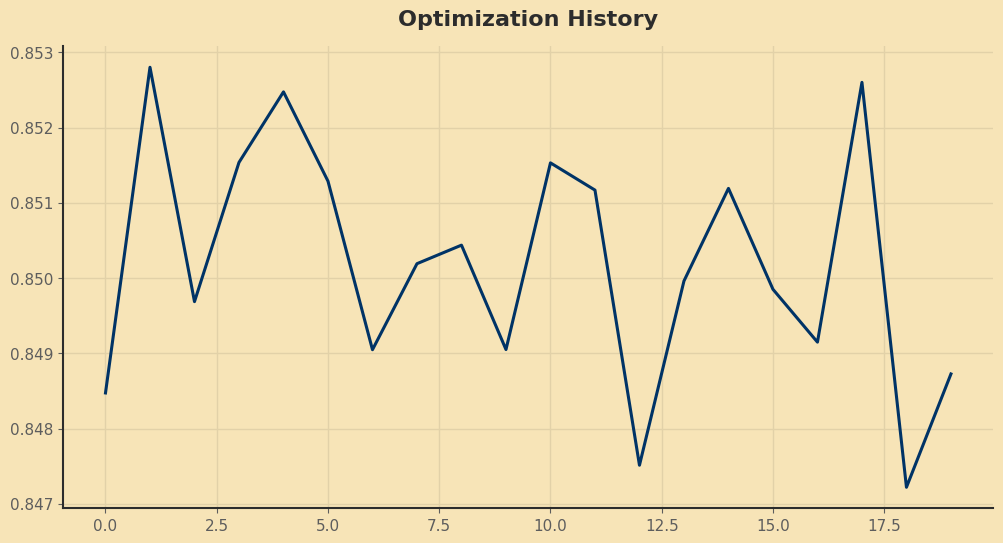

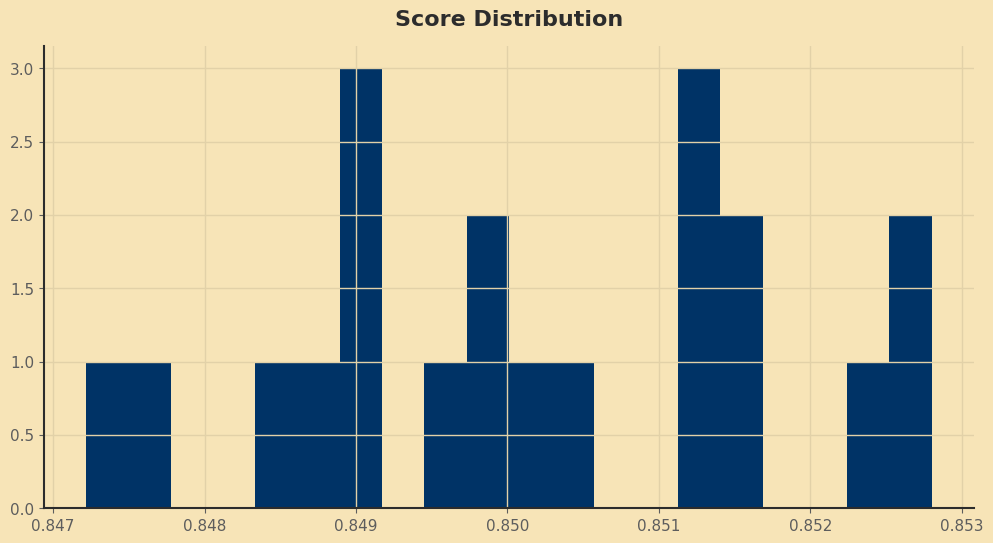

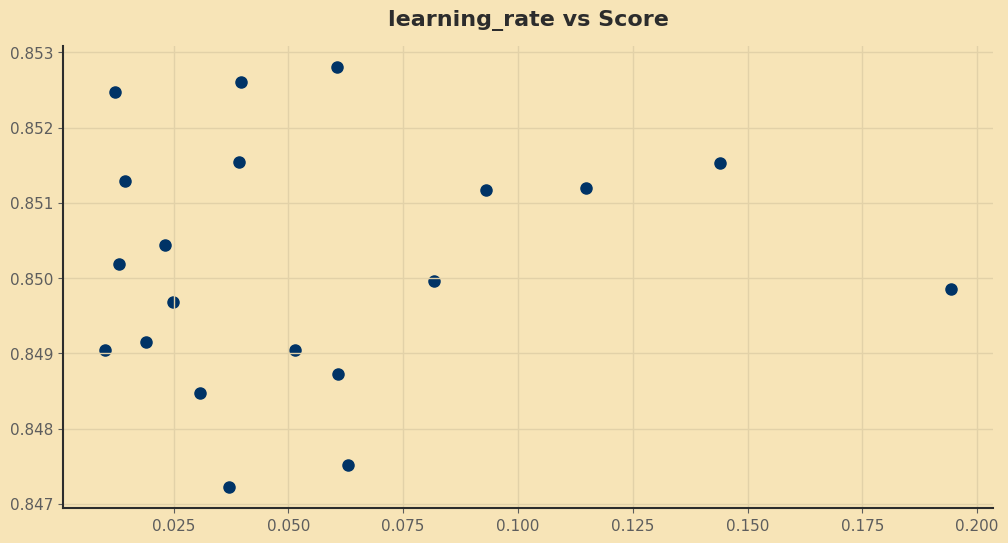

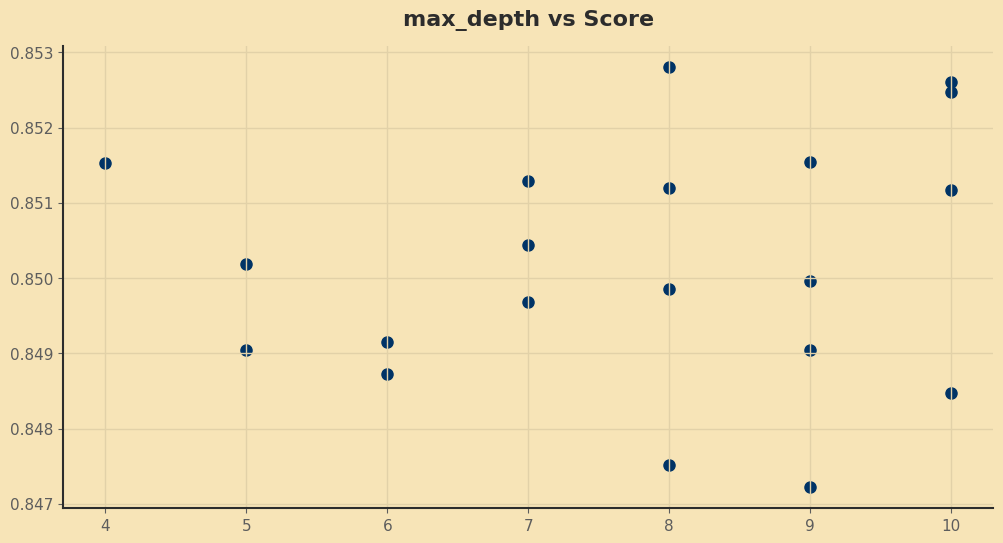

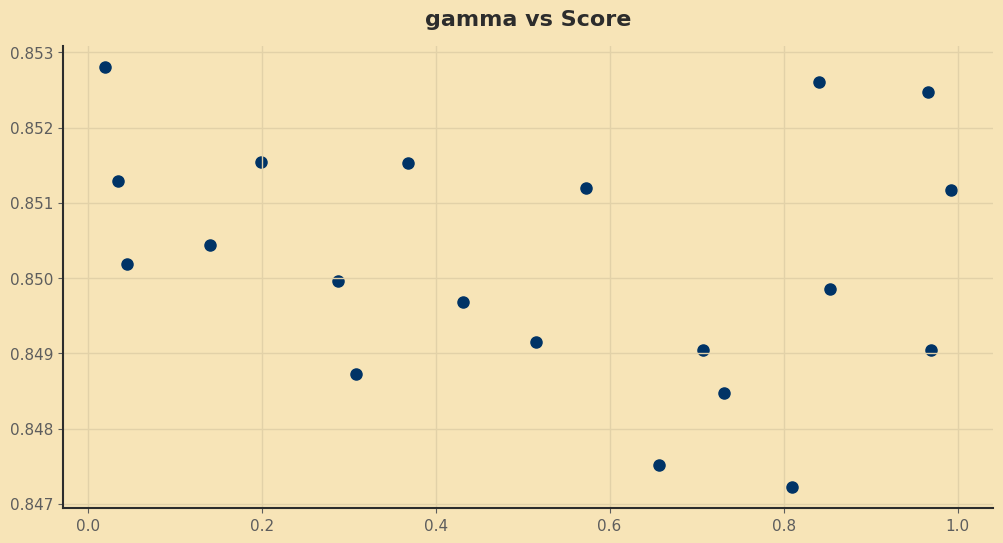

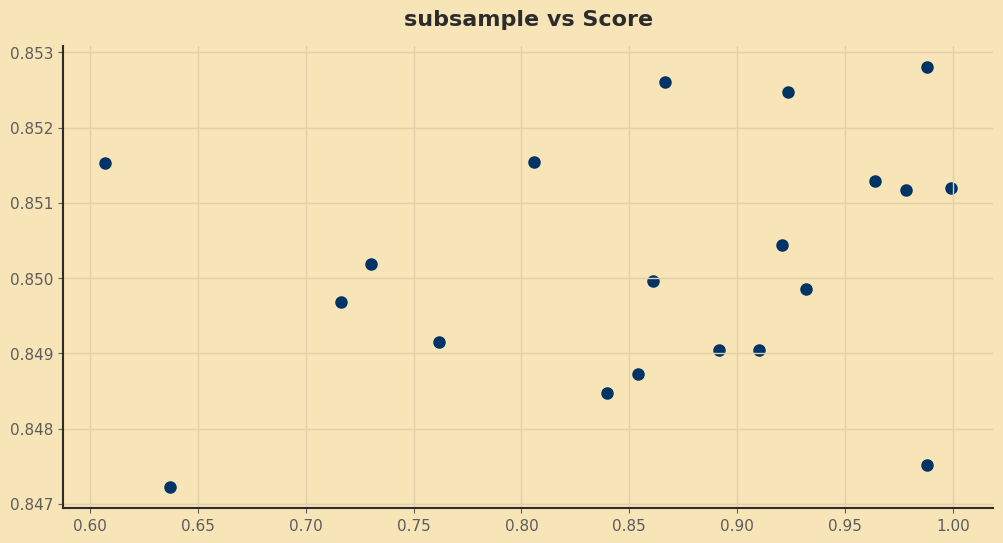

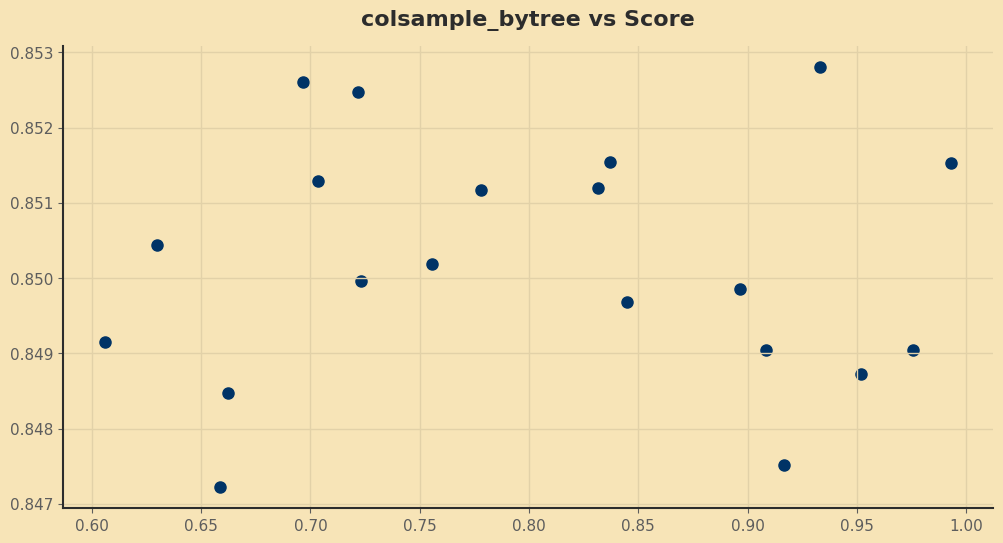

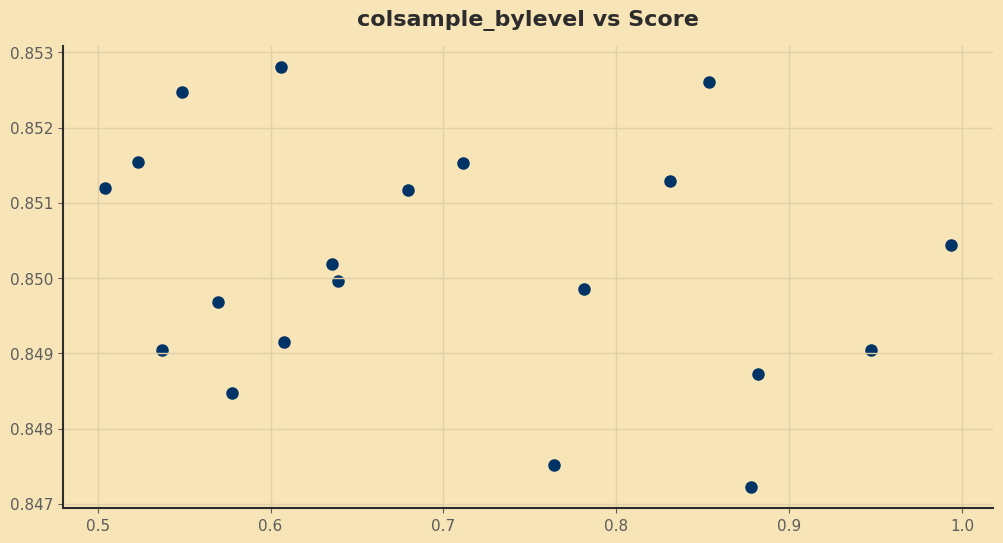

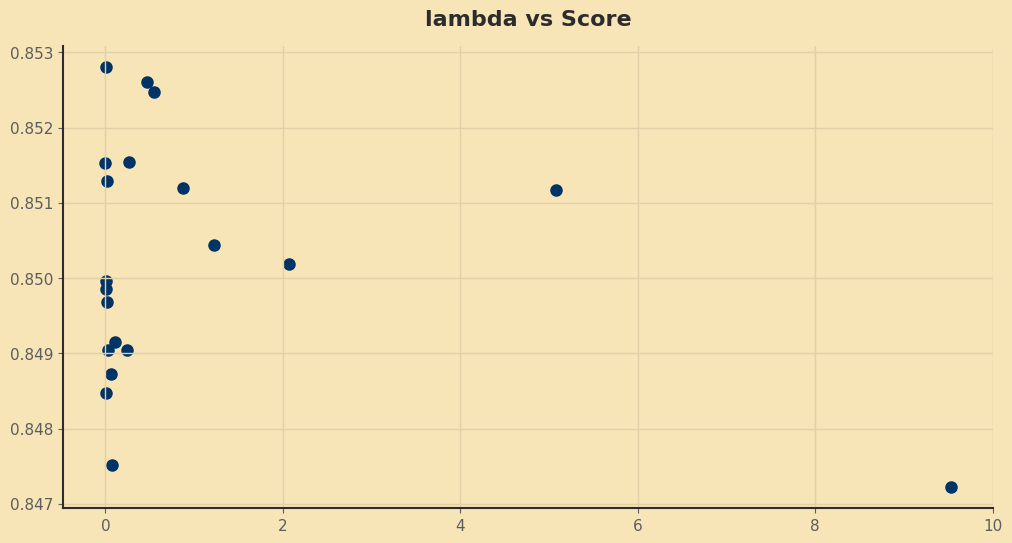

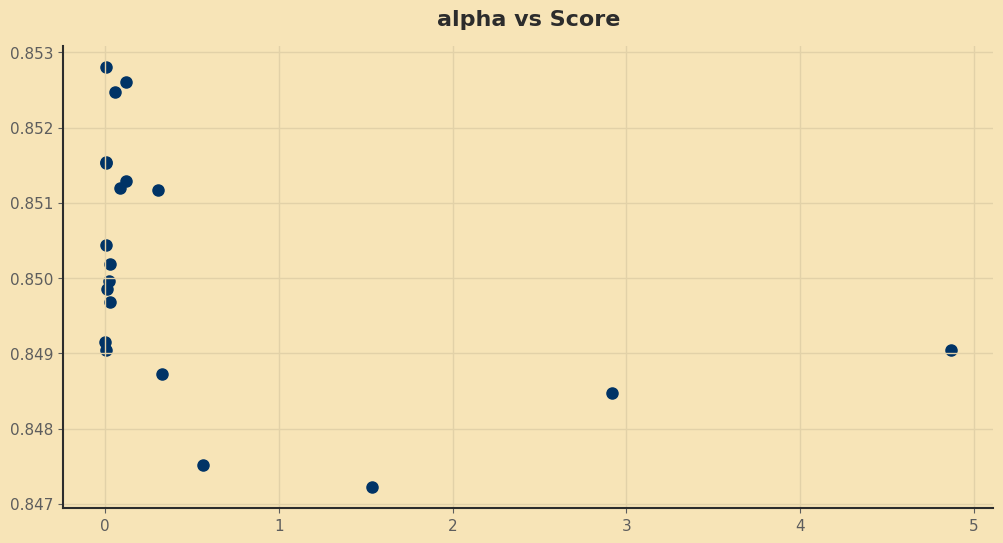

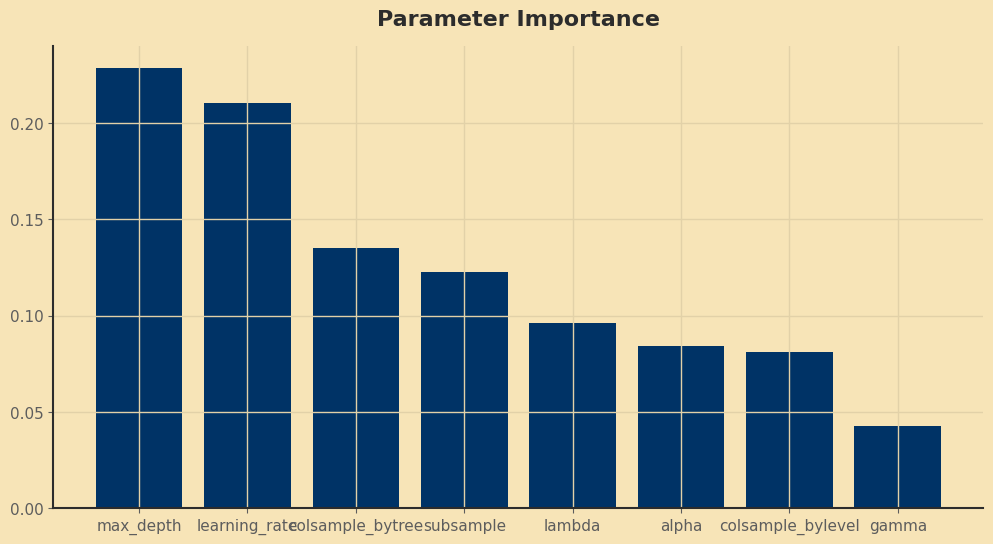

[0]	train-ndcg@5:0.85913	train-map@5:0.80472	test-ndcg@5:0.85845	test-map@5:0.80382
[50]	train-ndcg@5:0.87297	train-map@5:0.82275	test-ndcg@5:0.86959	test-map@5:0.81881
[100]	train-ndcg@5:0.87575	train-map@5:0.82618	test-ndcg@5:0.87000	test-map@5:0.81934
[150]	train-ndcg@5:0.87838	train-map@5:0.82944	test-ndcg@5:0.87020	test-map@5:0.81971
[191]	train-ndcg@5:0.88018	train-map@5:0.83169	test-ndcg@5:0.87014	test-map@5:0.81960


2026/03/21 12:06:57 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/21 12:06:57 INFO mlflow.store.db.utils: Updating database tables
2026/03/21 12:07:04 INFO mlflow.tracking.fluent: Experiment with name 'LTR_XGB_RANKER' does not exist. Creating a new experiment.


Model training completed and saved.


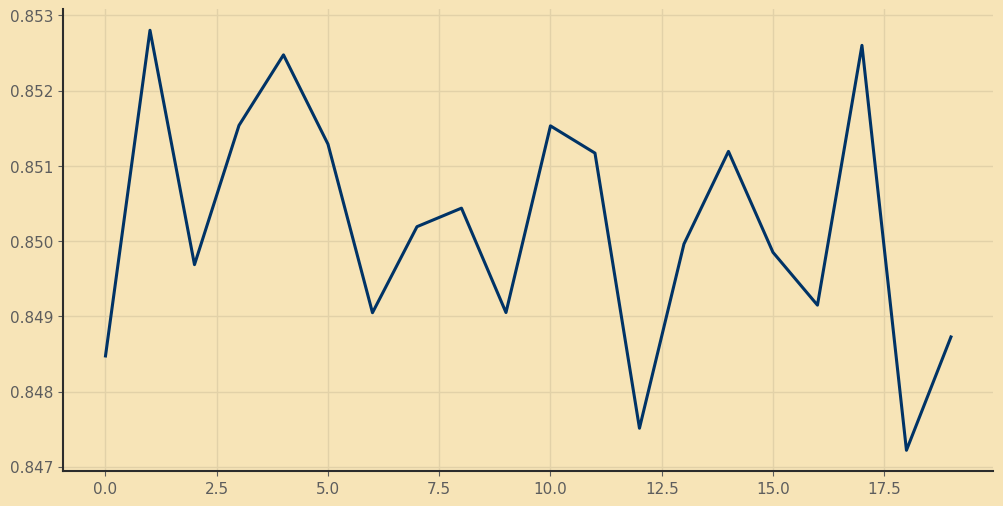

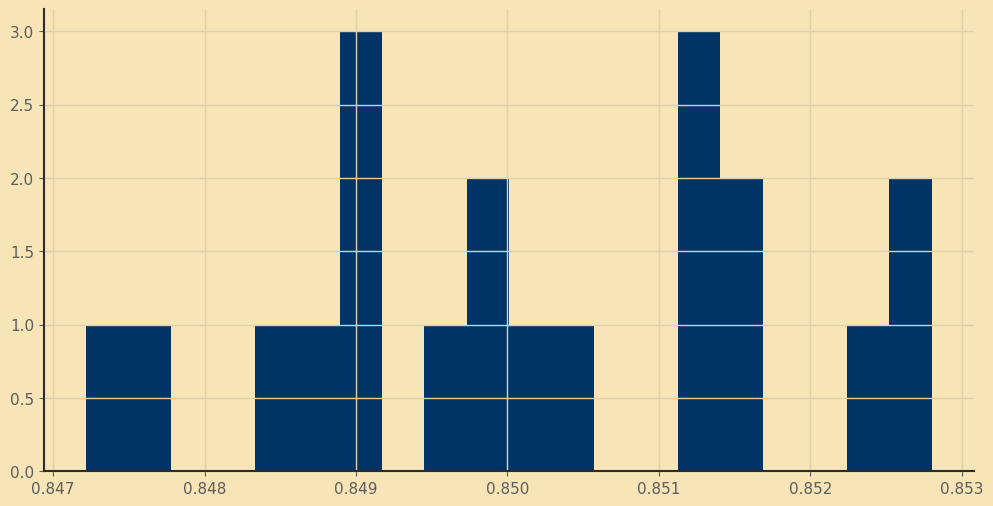

In [52]:
import xgboost as xgb
import optuna
import numpy as np
import time
import warnings
import logging
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import GroupKFold
import ray
import pandas as pd
import re


@ray.remote
def train_fold_remote(params, X_tr, y_tr, qid_tr, X_va, y_va, qid_va):
    # Sort by query_id (IMPORTANT for group sizes)
    def prepare(X, y, qid):
        df = pd.DataFrame({"qid": qid, "idx": np.arange(len(qid))})
        df = df.sort_values("qid")
        group_sizes = df.groupby("qid").size().values
        X_sorted = X[df["idx"].values]
        y_sorted = y[df["idx"].values]
        return X_sorted, y_sorted, group_sizes

    X_tr, y_tr, g_tr = prepare(X_tr, y_tr, qid_tr)
    X_va, y_va, g_va = prepare(X_va, y_va, qid_va)

    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dtrain.set_group(g_tr)

    dvalid = xgb.DMatrix(X_va, label=y_va)
    dvalid.set_group(g_va)

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=150,   # faster tuning
        evals=[(dvalid, "valid")],
        early_stopping_rounds=20,
        verbose_eval=False
    )

    eval_str = model.eval(dvalid)
    ndcg = float(re.search(r"ndcg@5:([0-9.]+)", eval_str).group(1))
    map_score = float(re.search(r"map@5:([0-9.]+)", eval_str).group(1))

    return ndcg, map_score


class AdvancedXGBRanker:

    def __init__(
        self,
        X_train, y_train, group_sizes_train, query_ids_train,
        X_test, y_test, group_sizes_test, query_ids_test,
        n_splits=3,
        n_trials=20,
        sample_ratio=0.2,
        random_state=42,
        metric_weights={"ndcg": 0.7, "map": 0.3},
        use_ray=True,
        log_level=logging.INFO
    ):
        self.X_train = X_train
        self.y_train = y_train
        self.group_sizes_train = group_sizes_train
        self.query_ids_train = query_ids_train

        self.X_test = X_test
        self.y_test = y_test
        self.group_sizes_test = group_sizes_test
        self.query_ids_test = query_ids_test

        self.n_splits = n_splits
        self.n_trials = n_trials
        self.sample_ratio = sample_ratio
        self.random_state = random_state
        self.metric_weights = metric_weights
        self.use_ray = use_ray

        self.best_params = None
        self.best_model = None
        self.study = None

        # Logging
        if not logging.getLogger().hasHandlers():
            logging.basicConfig(level=log_level)
        self.logger = logging.getLogger(self.__class__.__name__)

        # Ray init
        if self.use_ray and not ray.is_initialized():
            ray.init(ignore_reinit_error=True)

        # Full DMatrix for final training
        self.dtrain_full = xgb.DMatrix(self.X_train, label=self.y_train)
        self.dtrain_full.set_group(self.group_sizes_train)

        self.dtest = xgb.DMatrix(self.X_test, label=self.y_test)
        self.dtest.set_group(self.group_sizes_test)

    # =========================
    # Sampling (QUERY LEVEL)
    # =========================
    def _sample_data(self):
        unique_q = np.unique(self.query_ids_train)
        n_sample = max(1, int(len(unique_q) * self.sample_ratio))

        sampled_q = np.random.choice(unique_q, n_sample, replace=False)
        mask = np.isin(self.query_ids_train, sampled_q)

        return (
            self.X_train[mask],
            self.y_train[mask],
            self.query_ids_train[mask]
        )

    # =========================
    # Objective
    # =========================
    def _objective(self, trial):
        try:
            X_s, y_s, q_s = self._sample_data()

            params = {
                "objective": "rank:ndcg",
                "eval_metric": ["ndcg@5", "map@5"],
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "max_depth": trial.suggest_int("max_depth", 4, 10),
                "gamma": trial.suggest_float("gamma", 0.0, 1.0),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
                "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),
                "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
                "tree_method": "hist",
                "verbosity": 0,
                "nthread": 1 if self.use_ray else -1,
                "seed": self.random_state,
            }

            gkf = GroupKFold(n_splits=self.n_splits)
            folds = list(gkf.split(X_s, y_s, groups=q_s))

            scores = list()

            if self.use_ray:
                futures = list()
                for tr_idx, va_idx in folds:
                    futures.append(
                        train_fold_remote.remote(
                            params,
                            X_s[tr_idx], y_s[tr_idx], q_s[tr_idx],
                            X_s[va_idx], y_s[va_idx], q_s[va_idx]
                        )
                    )

                results = ray.get(futures)

            else:
                results = [
                    train_fold_remote.func(
                        params,
                        X_s[tr], y_s[tr], q_s[tr],
                        X_s[va], y_s[va], q_s[va]
                    )
                    for tr, va in folds
                ]

            for i, (ndcg, map_score) in enumerate(results):
                score = (
                    self.metric_weights["ndcg"] * ndcg +
                    self.metric_weights["map"] * map_score
                )
                scores.append(score)

                trial.report(score, step=i)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()

            return np.mean(scores)

        except optuna.exceptions.TrialPruned:
            raise
        except Exception as e:
            self.logger.exception("Objective failed")
            raise e

    # =========================
    # Optimize
    # =========================
    def optimize(self):
        self.logger.info("Starting optimization")

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            self.study = optuna.create_study(
                direction="maximize",
                sampler=optuna.samplers.TPESampler(seed=self.random_state),
                pruner=optuna.pruners.MedianPruner()
            )

            pbar = tqdm(total=self.n_trials)

            def cb(study, trial):
                pbar.update(1)

            self.study.optimize(self._objective, n_trials=self.n_trials, callbacks=[cb])
            pbar.close()

        self.best_params = self.study.best_params
        self.logger.info(f"Best Score: {self.study.best_value}")

    # =========================
    # Final Training (FULL DATA)
    # =========================
    def train_final(self):
        self.logger.info("Training final model on full data")

        params = {
            **self.best_params,
            "objective": "rank:ndcg",
            "eval_metric": ["ndcg@5", "map@5"],
            "tree_method": "hist",
            "nthread": -1,
            "verbosity": 1,
            "seed": self.random_state,
        }

        self.best_model = xgb.train(
            params,
            self.dtrain_full,
            num_boost_round=400,
            evals=[(self.dtrain_full, "train"), (self.dtest, "test")],
            early_stopping_rounds=50,
            verbose_eval=50
        )

    # =========================
    def evaluate(self):
        result = self.best_model.eval(self.dtest)
        self.logger.info(f"Test result: {result}")
        return result

    def plot_reports(self):
        self.logger.info("Generating Optuna reports and visualizations")

        try:
            import optuna.visualization as vis

            trials = self.study.trials
            values = [t.value for t in trials if t.value is not None]

            # 1. Optimization History
            plt.figure()
            plt.plot(values)
            plt.title("Optimization History")

            # 2. Score Distribution
            plt.figure()
            plt.hist(values, bins=20)
            plt.title("Score Distribution")

            # 3. Parameter vs Score (scatter)
            for param in self.best_params.keys():
                param_vals = [t.params.get(param) for t in trials if param in t.params]
                aligned_vals = values[:len(param_vals)]

                plt.figure()
                plt.scatter(param_vals, aligned_vals)
                plt.title(f"{param} vs Score")

            # 4. Param Importance
            importances = optuna.importance.get_param_importances(self.study)
            plt.figure()
            plt.bar(importances.keys(), importances.values())
            plt.title("Parameter Importance")

            # --- Optuna Interactive Plots ---
            try:
                vis.plot_optimization_history(self.study).show()
                vis.plot_param_importances(self.study).show()
                vis.plot_parallel_coordinate(self.study).show()
                vis.plot_slice(self.study).show()
                vis.plot_contour(self.study).show()
                vis.plot_edf(self.study).show()
            except Exception:
                self.logger.warning("Interactive plots failed (likely notebook issue)")

            plt.show()

        except Exception as e:
            self.logger.exception("Plotting failed")
            raise e

    # =========================
    def __call__(self):
        start = time.time()

        self.optimize()
        self.plot_reports()
        self.train_final()
        self.evaluate()

        # =========================
        # CALL TRACKER API
        # =========================
        tracker = ExperimentTracker(
            study=self.study,
            best_model=self.best_model
        )

        report_info = tracker.run()

        runtime = (time.time() - start) / 60
        self.logger.info(f"Total runtime: {runtime:.2f} minutes")
        self.logger.info(f"Report saved: {report_info}")

        return self.best_model

if __name__ == '__main__':
    import numpy as np
    import logging

    # =========================
    # Logging Configuration
    # =========================
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
    )

    # =========================
    # Initialize Ranker
    # =========================

    ranker = AdvancedXGBRanker(
        X_train = X_train,
        y_train = y_train,
        group_sizes_train = group_train, # Passing array of group counts
        query_ids_train = q_train,       # Passing array of user_ids for GroupKFold
        X_test = X_test,
        y_test = y_test,
        group_sizes_test = group_test,   # Passing array of group counts
        query_ids_test = q_test,         # Passing array of user_ids for GroupKFold
        n_splits=5,
        n_trials=20,
    )

    # =========================
    # Run Full Pipeline
    # =========================
    model = ranker()

    # =========================
    # Save Model (Optional)
    # =========================
    model.save_model("/content/xgb_ranker_model_02.json")

    print("Model training completed and saved.")